<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_1s_100hz_initial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training of lab 1s 10b0hz balanced 7class dataset

In [ ]:
# Author: Ziyi Liu
# Project: Bachelor's Thesis - Cyclist Curb Detection under Varying Road Roughness
# Institution: Universität Kassel
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

## 1. load data

In [1]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s_100hz_7class/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s_100hz_7class/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../data_1s_100hz_7class/TrainTest/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s_100hz_7class/TrainTest/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../data_1s_100hz_7class/TrainTest/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s_100hz_7class/TrainTest/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_labels.shape

((2788, 100, 3), (2788, 7), (698, 100, 3), (698, 7), (872, 7))

In [2]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 920, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 920 (delta 29), reused 54 (delta 26), pack-reused 853 (from 1)
Receiving objects: 100% (920/920), 231.80 MiB | 10.01 MiB/s, done.
Resolving deltas: 100% (566/566), done.
Updating files: 100% (99/99), done.


/content/Bachelorarbeit/notebooks/training/transformations.py:35: SyntaxWarning: invalid escape sequence '\&'
  @inproceedings{TerryUm_ICMI2017, author = {Um, Terry T. and Pfister, Franz M. J. and Pichler, Daniel and Endo, Satoshi and Lang, Muriel and Hirche, Sandra and Fietzek, Urban and Kuli\'{c}, Dana}, title = {Data Augmentation of Wearable Sensor Data for Parkinson's Disease Monitoring Using Convolutional Neural Networks}, booktitle = {Proceedings of the 19th ACM International Conference on Multimodal Interaction}, series = {ICMI 2017}, year = {2017}, isbn = {978-1-4503-5543-8}, location = {Glasgow, UK}, pages = {216--220}, numpages = {5}, doi = {10.1145/3136755.3136817}, acmid = {3136817}, publisher = {ACM}, address = {New York, NY, USA}, keywords = {Parkinson\&#39;s disease, convolutional neural networks, data augmentation, health monitoring, motor state detection, wearable sensor}, }


--2025-10-26 08:53:10--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6691365 (6.4M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   6.38M  --.-KB/s    in 0.02s   

2025-10-26 08:53:11 (289 MB/s) - ‘X_train_normalized.pkl’ saved [6691365/6691365]

--2025-10-26 08:53:11--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz_7class/TrainTest/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubus

## 2 Pretraining with SimCLR

In [3]:
# Parameters for all experiments
window_size = 100
input_shape = (window_size, 3)
batch_size = 512
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 200
temperature = 0.1


In [4]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x7af3cb767100>
1 <function channel_shuffle_transform_vectorized at 0x7af3cb767060>


In [5]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [6]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 77, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 62, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 12.308
epoch: 2 loss: 11.610
epoch: 3 loss: 10.568
epoch: 4 loss: 10.417
epoch: 5 loss: 9.593
epoch: 6 loss: 10.803
epoch: 7 loss: 9.882
epoch: 8 loss: 9.197
epoch: 9 loss: 8.927
epoch: 10 loss: 8.798
epoch: 11 loss: 8.846
epoch: 12 loss: 8.192
epoch: 13 loss: 7.991
epoch: 14 loss: 7.987
epoch: 15 loss: 7.629
epoch: 16 loss: 7.856
epoch: 17 loss: 7.471
epoch: 18 loss: 7.002
epoch: 19 loss: 7.627
epoch: 20 loss: 6.904
epoch: 21 loss: 7.117
epoch: 22 loss: 7.129
epoch: 23 loss: 6.748
epoch: 24 loss: 6.664
epoch: 25 loss: 6.722
epoch: 26 loss: 6.466
epoch: 27 loss: 6.441
epoch: 28 loss: 6.399
epoch: 29 loss: 6.111
epoch: 30 loss: 6.264
epoch: 31 loss: 6.062
epoch: 32 loss: 5.925
epoch: 33 loss: 5.842
epoch: 34 loss: 5.755
epoch: 35 loss: 5.988
epoch: 36 loss: 5.641
epoch: 37 loss: 5.647
epoch: 38 loss: 5.545
epoch: 39 loss: 5.362
epoch: 40 loss: 5.347
epoch: 41 loss: 5.250
epoch: 42 loss: 5.174
epoch: 43 loss: 5.127
epoch: 44 loss: 5.051
epoch: 45 loss: 5.202
epoch: 46 loss

epoch: 200 loss: 2.388


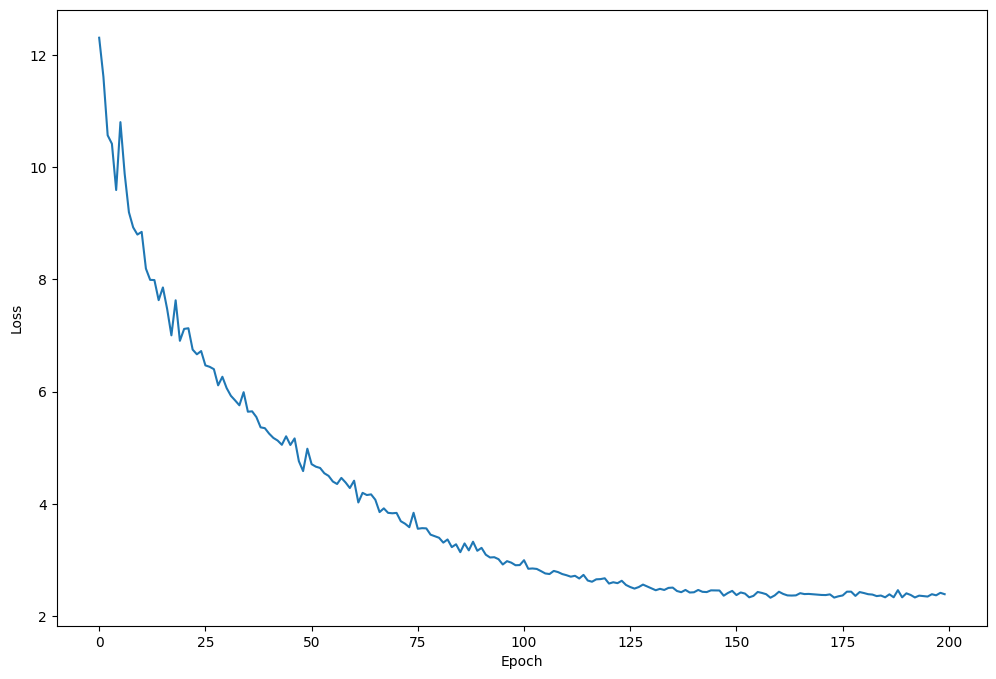

In [7]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 3 Fine-tuning and Evaluation

### Linear Model

#### Train

In [8]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 557ms/step - auc: 0.6712 - categorical_accuracy: 0.2850 - loss: 1.8554 - precision: 0.4558 - recall: 0.0762 - val_auc: 0.8134 - val_categorical_accuracy: 0.4355 - val_loss: 1.5108 - val_precision: 0.8704 - val_recall: 0.1347
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.8233 - categorical_accuracy: 0.4632 - loss: 1.4550 - precision: 0.8713 - recall: 0.1731 - val_auc: 0.8327 - val_categorical_accuracy: 0.4842 - val_loss: 1.4357 - val_precision: 0.8836 - val_recall: 0.1848
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.8418 - categorical_accuracy: 0.4969 - loss: 1.3829 - precision: 0.8762 - recall: 0.2081 - val_auc: 0.8405 - val_categorical_accuracy: 0.5201 - val_loss: 1.3963 - val_precision: 0.8642 - val_recall: 0.2006
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.8500 - categorical_accuracy: 0.5094 - loss: 1.3462 - precision: 0.8818 - recall: 0.2248 - val_auc: 0.8467 - val_categorical_accuracy: 0.5344 - 

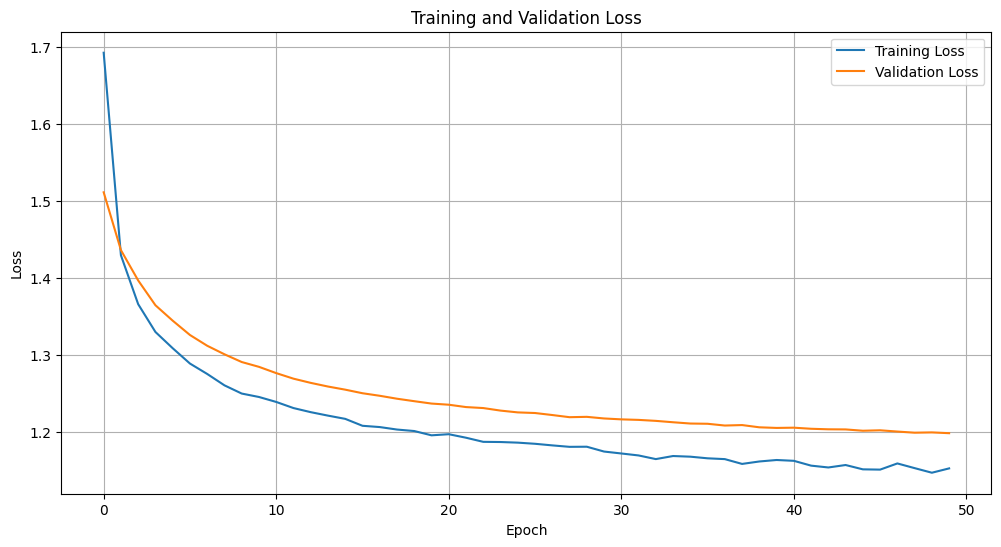

In [9]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

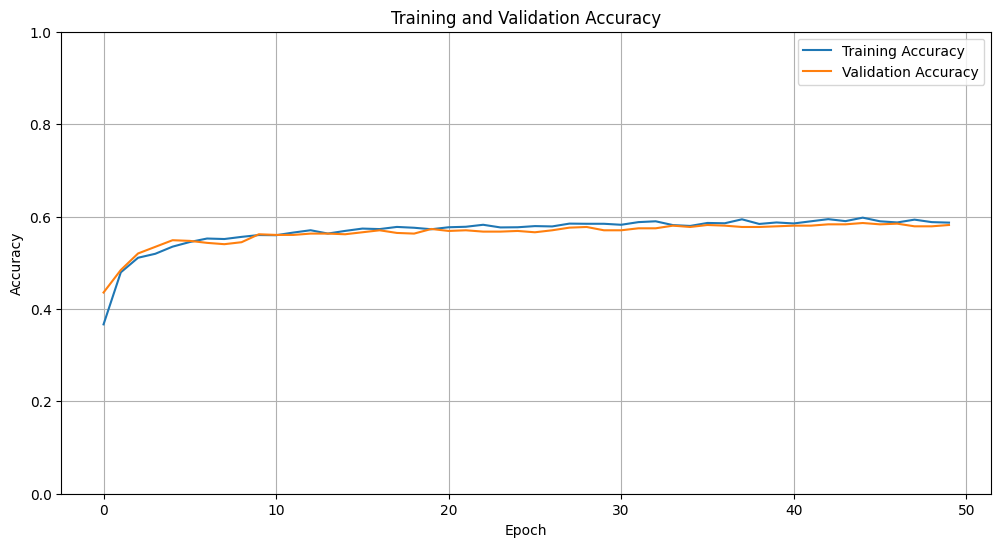

In [10]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [11]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [12]:
from sklearn.preprocessing import StandardScaler

def normalize_3d_data(data):
    """
    Normalize 3D sensor data (samples, timesteps, features) using StandardScaler.

    Parameters:
    -----------
    data : list or numpy.ndarray
        Input data. If a list of arrays, it will be stacked first.
        Shape should be (N, L, C) where:
        N = number of samples, L = segment length (timesteps), C = number of channels/features

    Returns:
    --------
    numpy.ndarray
        Normalized data with the same shape as input
    """
    # Stack data if it's a list
    if isinstance(data, list):
        data_array = np.stack(data)  # shape: (N, L, C)
    else:
        data_array = data

    # Get dimensions
    N, L, C = data_array.shape

    # Reshape to 2D for scaling: (N*L, C)
    data_reshaped = data_array.reshape(-1, C)

    # Apply standard scaling
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_reshaped)

    # Reshape back to original 3D shape
    data_normalized = data_scaled.reshape(N, L, C)

    return data_normalized

In [13]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [15]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
{'Confusion Matrix': array([[105,   1,   9,   7,   0,   2,  15],
       [  6,  98,   5,   7,   3,   7,   5],
       [ 37,   7,  28,   4,   2,  14,  31],
       [ 10,   2,   1,  82,   3,  10,  10],
       [  0,   5,   1,   2, 109,   1,   0],
       [ 19,   8,   7,   5,   0,  60,  16],
       [ 33,   5,   7,   7,   0,  29,  47]]), 'F1 Macro': 0.597933008168337, 'F1 Micro': 0.606651376146789, 'F1 Weighted': 0.5965684401378178, 'Precision': 0.6111851016883852, 'Recall': 0.6055286087372613, 'Kappa': np.float64(0.5400497324994349)}
Model in last epoch
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
{'Confusion Matrix': array([[105,   1,   9,   7,   0,   2,  15],
       [  6,  98,   5,   7,   3,   7,   5],
       [ 37,   7,  28,   4,   2,  14,  31],
       [ 10,   2,   1,  82,   3,  10,  10],
       [  0,   5,   1,   2, 109,   1,   0],
       [ 19,   8,   7,   5,   0,  60,  16],
       [ 33,   5,   7,   7,   0,  29,  47]]), 'F

### Full HAR Model

#### Train

In [14]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - auc: 0.6960 - categorical_accuracy: 0.3279 - loss: 1.9097 - precision: 0.6452 - recall: 0.1487 - val_auc: 0.8588 - val_categorical_accuracy: 0.5372 - val_loss: 1.2830 - val_precision: 0.8228 - val_recall: 0.2794
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.8666 - categorical_accuracy: 0.5534 - loss: 1.2511 - precision: 0.7804 - recall: 0.3631 - val_auc: 0.8788 - val_categorical_accuracy: 0.5802 - val_loss: 1.2077 - val_precision: 0.8431 - val_recall: 0.3080
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.8903 - categorical_accuracy: 0.5906 - loss: 1.1477 - precision: 0.7886 - recall: 0.3776 - val_auc: 0.8907 - val_categorical_accuracy: 0.5845 - val_loss: 1.1455 - val_precision: 0.8713 - val_recall: 0.3395
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.9010 - categorical_accuracy: 0.6036 - loss: 1.0903 - precision: 0.8042 - recall: 0.3941 - val_auc: 0.8983 - val_categorical_accuracy: 0.5874 - val

#### Plot metrics

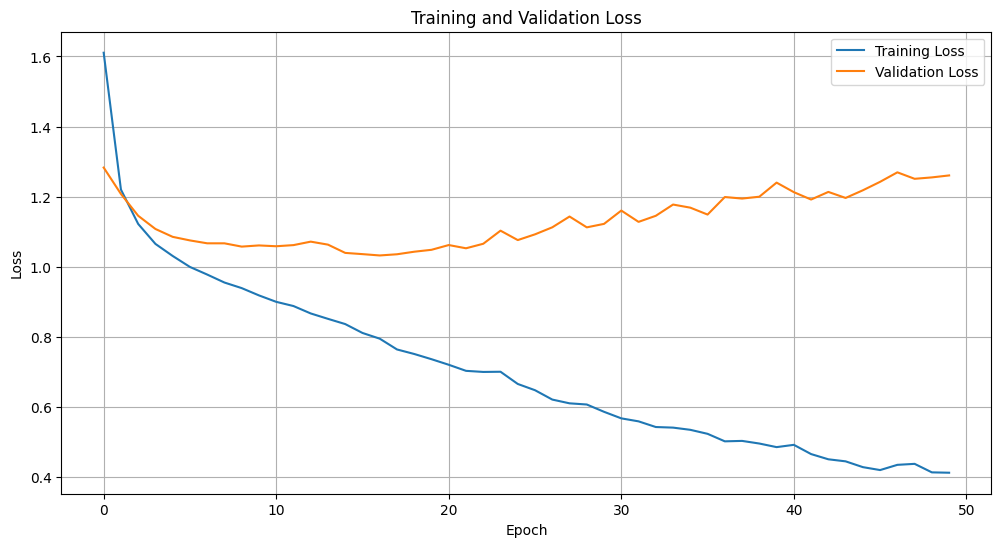

In [16]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

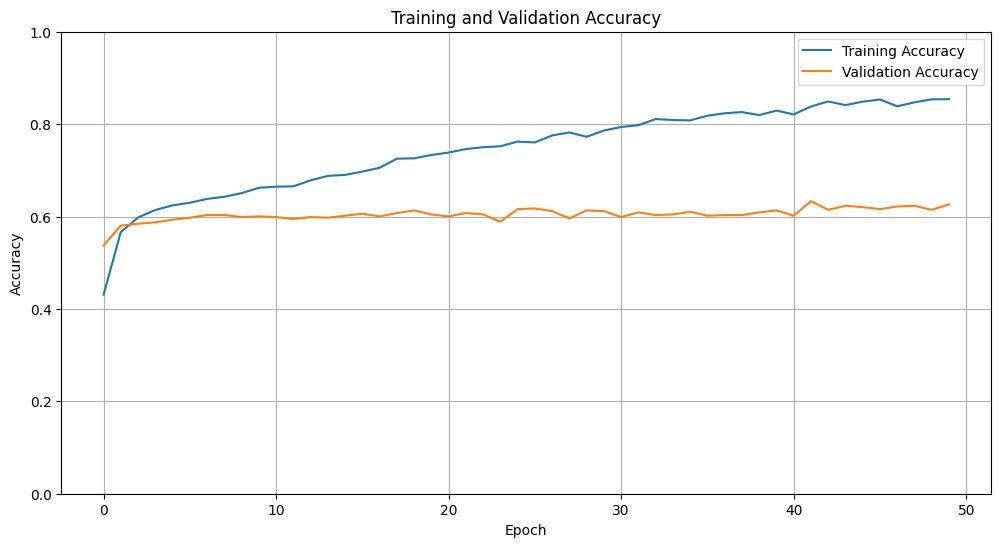

In [17]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [18]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step
{'Confusion Matrix': array([[108,   1,  14,   4,   0,   2,  10],
       [  7, 104,   4,   4,   2,   6,   4],
       [ 31,   3,  35,   4,   1,  21,  28],
       [  7,   1,   2,  87,   3,  10,   8],
       [  0,   2,   0,   1, 115,   0,   0],
       [ 17,   2,   7,  11,   0,  58,  20],
       [ 32,   5,   5,   7,   0,  24,  55]]), 'F1 Macro': 0.6375903953413443, 'F1 Micro': 0.6444954128440367, 'F1 Weighted': 0.6370716882658327, 'Precision': 0.6493482369943343, 'Recall': 0.6430463036331789, 'Kappa': np.float64(0.5844363479838276)}
Model in last epoch
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
{'Confusion Matrix': array([[100,   1,  15,   3,   1,   5,  14],
       [  5, 105,   6,   3,   2,   5,   5],
       [ 28,   5,  39,   0,   1,  21,  29],
       [  4,   3,   3,  85,   3,  11,   9],
       [  0,   2,   0,   0, 115,   1,   0],
       [ 11,   4,  10,   7,   0,  66,  17],
       [ 32,   4,  10,   6,   0,  22,  54]]), 

## Extra: t-SNE Plots

### Parameters

In [19]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [20]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 77, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 62, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 872 samples in 0.000s...
[t-SNE] Computed neighbors for 872 samples in 0.069s...
[t-SNE] Computed conditional probabilities for sample 872 / 872
[t-SNE] Mean sigma: 1.683033
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.413754
[t-SNE] KL divergence after 1000 iterations: 0.703964


### Plotting

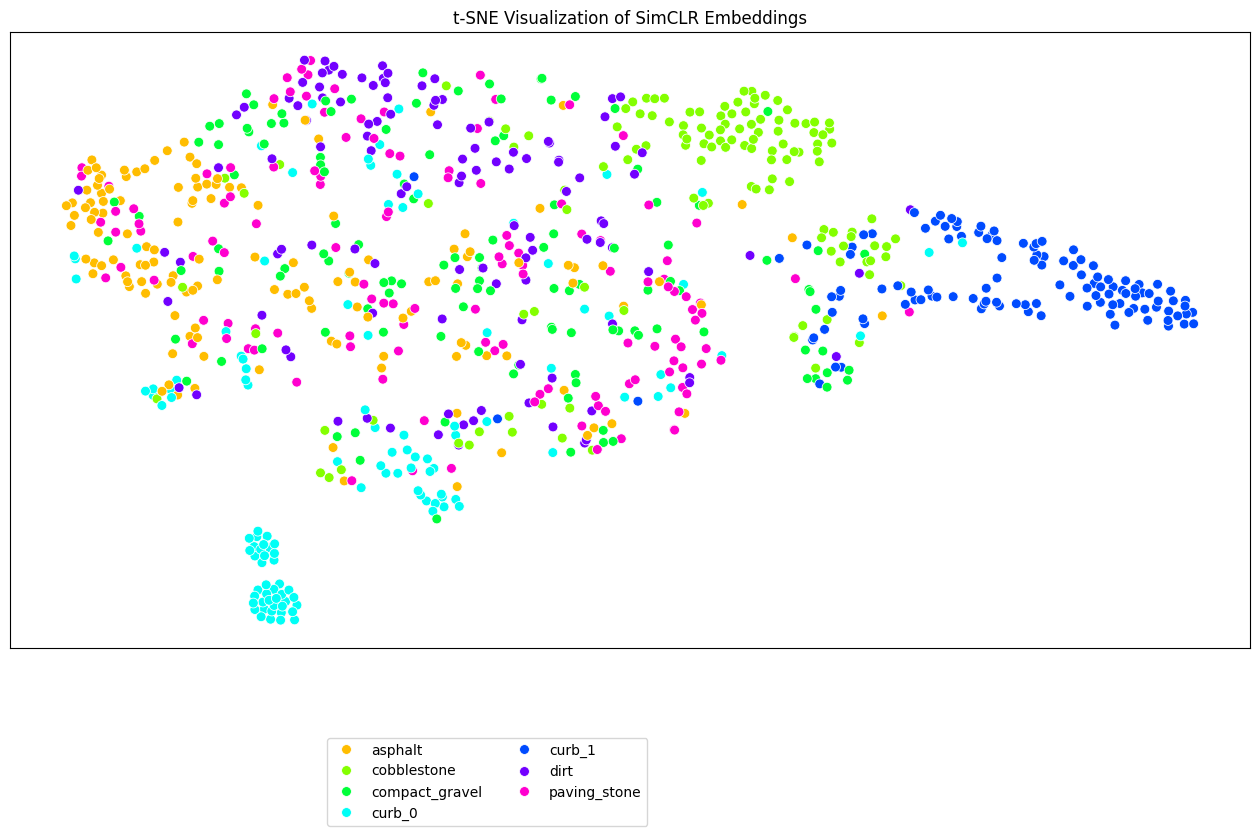

In [21]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)

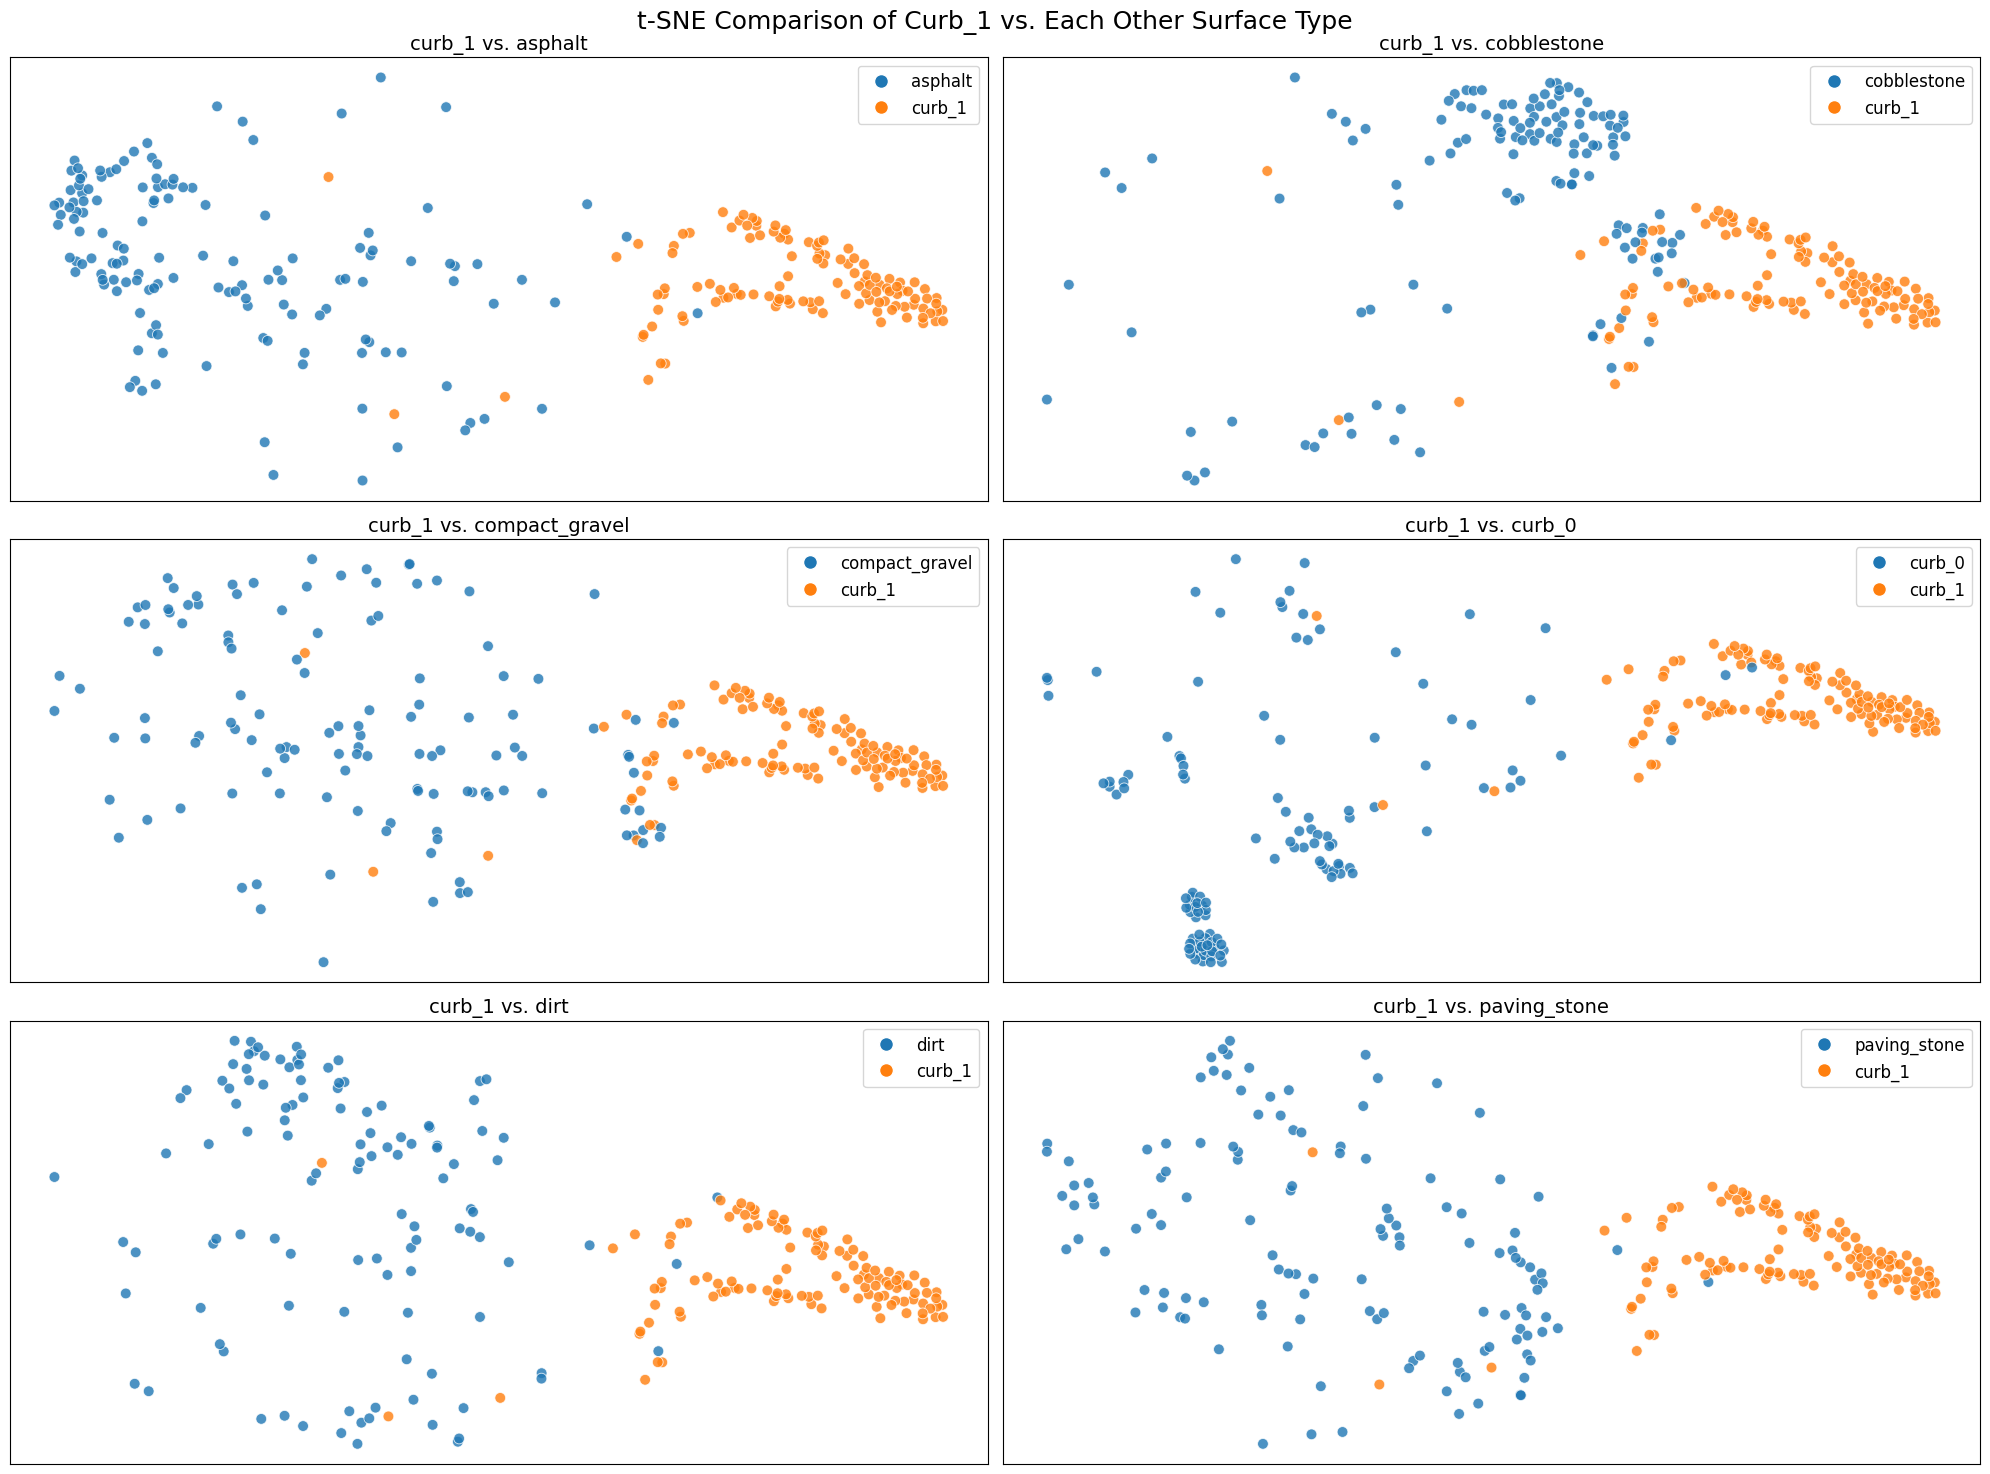

In [26]:
# Create a figure with 6 subplots (3x2 grid) to compare curb_1 with each other class
plt.figure(figsize=(20, 15))

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)
curb_1_index = 4  # Based on your label_list_full_name where "curb_1" is at index 4

# Define your surface type names
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]

# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Loop through each class (except curb_1) and create a subplot
subplot_index = 1
for class_index in unique_labels:
    # Skip curb_1 as we're comparing others against it
    if class_index == curb_1_index:
        continue

    # Create binary mask for current pair (curb_1 and current class)
    mask = np.logical_or(labels_argmax == curb_1_index, labels_argmax == class_index)

    # Create binary labels: 0 for current class, 1 for curb_1
    binary_labels = np.zeros(np.sum(mask))
    binary_labels[labels_argmax[mask] == curb_1_index] = 1

    # Get the filtered t-SNE projections
    filtered_projections = tsne_projections[mask]

    # Create subplot
    plt.subplot(3, 2, subplot_index)

    # Plot the scatter points
    sns.scatterplot(
        x=filtered_projections[:, 0],
        y=filtered_projections[:, 1],
        hue=binary_labels,
        palette=[other_class_color, curb_1_color],  # Blue for other class, Yellow for curb_1
        s=60,
        alpha=0.8
    )

    # Remove axes ticks for cleaner visualization
    plt.xticks([], [])
    plt.yticks([], [])

    # Set subplot title
    plt.title(f"curb_1 vs. {label_list_full_name[class_index]}", fontsize=14)

    # Custom legend with specific colors
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=other_class_color, markersize=10,
                  label=label_list_full_name[class_index]),
        plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=curb_1_color, markersize=10,
                  label='curb_1')
    ]
    plt.legend(handles=legend_elements, fontsize=12)

    # Increment subplot index
    subplot_index += 1

# Add overall title
plt.suptitle("t-SNE Comparison of Curb_1 vs. Each Other Surface Type", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()